<a href="https://colab.research.google.com/github/pranx18/mental_health_in_students/blob/main/NLP_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# 📦 Step 1: Install Dependencies
# ================================
!pip install textblob nltk

# ================================
# 📚 Step 2: Import Libraries
# ================================
import pandas as pd
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string

nltk.download('stopwords')

# ================================
# 📊 Step 3: Create Dataset
# ================================
data = {
    "review": [
        "This product is amazing, I love it!",
        "Worst purchase ever, very disappointed",
        "Average quality, okay for the price",
        "Excellent performance and great value",
        "Terrible experience, will not buy again",
        "Good product but delivery was late",
        "Very happy with the quality",
        "Not worth the money",
        "Superb! Highly recommend it",
        "Bad packaging and poor service"
    ]
}

df = pd.DataFrame(data)
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review
0,"This product is amazing, I love it!"
1,"Worst purchase ever, very disappointed"
2,"Average quality, okay for the price"
3,Excellent performance and great value
4,"Terrible experience, will not buy again"
5,Good product but delivery was late
6,Very happy with the quality
7,Not worth the money
8,Superb! Highly recommend it
9,Bad packaging and poor service


In [3]:
# ================================
# 🧠 Step 4: Sentiment Function
# ================================
def analyze_sentiment(review):
    polarity = TextBlob(review).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [4]:
# ================================
# 🔍 Step 5: Keyword Extraction
# ================================
def extract_keywords(text):
    stop_words = set(stopwords.words('english'))

    words = text.lower().split()
    words = [word.strip(string.punctuation) for word in words]

    filtered_words = [
        word for word in words
        if word not in stop_words and word.isalpha()
    ]

    return Counter(filtered_words).most_common(5)

In [5]:
# ================================
# 🚀 Step 6: Apply Analysis
# ================================
df["Sentiment"] = df["review"].apply(analyze_sentiment)
df["Keywords"] = df["review"].apply(extract_keywords)

df

,review,Sentiment,Keywords
0,"This product is amazing, I love it!",Positive,"[(product, 1), (amazing, 1), (love, 1)]"
1,"Worst purchase ever, very disappointed",Negative,"[(worst, 1), (purchase, 1), (ever, 1), (disapp..."
2,"Average quality, okay for the price",Positive,"[(average, 1), (quality, 1), (okay, 1), (price..."
3,Excellent performance and great value,Positive,"[(excellent, 1), (performance, 1), (great, 1),..."
4,"Terrible experience, will not buy again",Negative,"[(terrible, 1), (experience, 1), (buy, 1)]"
5,Good product but delivery was late,Positive,"[(good, 1), (product, 1), (delivery, 1), (late..."
6,Very happy with the quality,Positive,"[(happy, 1), (quality, 1)]"
7,Not worth the money,Negative,"[(worth, 1), (money, 1)]"
8,Superb! Highly recommend it,Positive,"[(superb, 1), (highly, 1), (recommend, 1)]"
9,Bad packaging and poor service,Negative,"[(bad, 1), (packaging, 1), (poor, 1), (service..."


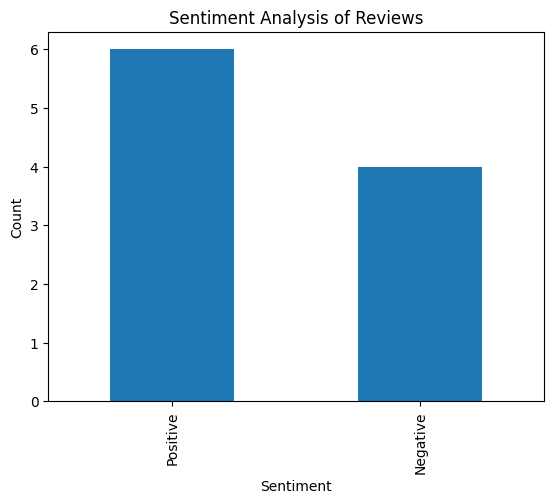

In [6]:
# ================================
# 📈 Step 8: Visualization
# ================================
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Analysis of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()